In [12]:
import os
import copy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import scipy 

import seaborn as sns
from IPython.display import Markdown as md

from matplotlib import ticker, cm

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib.patches import Ellipse

In [13]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
waiting = waiting[waiting != 108.0]

In [14]:
info_coord = (0.03, 0.8)
info_coord1 = (0.03, 0.97)
info_coord2 = (0.03, 0.87)

In [15]:
label_fontsize = 25
info_fontsize = 28
tick_fontsize = 20
legend_fontsize = 30
linewidth = 4.0

In [16]:
contam_data_list = np.arange(20, 182, 2) 
log_pen_list = np.arange(-12., 0.5, 0.5)
bw = 5.0
kernel_type = 'gaussian_poly2'

# file_name = f'../data/data=waiting-bw={bw}-kernel={kernel_type}-empirical-inf-fun-summary-baseden=Gamma-36-2-gridpoints=1-202-1.xlsx'
# summary_df_ml = pd.read_excel(file_name, f'ML-result')
# summary_df_sm = pd.read_excel(file_name, f'SM-result')

file_name = f'../data/data=waiting-bw={bw}-kernel={kernel_type}-contamweight=0.001-summary-baseden=Gamma-26-3-gridpoints=1-231-1.xlsx'
summary_df_sm = pd.read_excel(file_name, f'Sheet1')
summary_df_ml = pd.read_excel(file_name, f'ML-result')

summary_df_ml = summary_df_ml[(summary_df_ml.contam_data <= 180.0) & (summary_df_ml.contam_data >= 20.0)]
summary_df_sm = summary_df_sm[(summary_df_sm.contam_data <= 180.0) & (summary_df_sm.contam_data >= 20.0)]


## log density estimates and influence function

In [ ]:
savef = '../'
ml_folder = (savef + f'data/data=geyser-waiting-PenML-bw={bw}-kernel=gaussian_poly2-empirical-inf-fun-' + 
             f'plotdomain=(1.0, 210.0)-plotcnts=3000-seed=1-baseden=gamma-26.0-3.0-grid_points=1-181-1')

sm_folder = (savef + f'data/data=geyser-waiting-PenSM-FinKEF-bw={bw}-kernel=gaussian_poly2-empirical-inf-fun-' + 
             f'plotdomain=(1.0, 210.0)-plotcnts=3000-baseden=26.0-3.0-grid_points=1-181-1')

In [ ]:
from dekef.base_density import *
xlimit = (1., 210.)
plot_pts_cnt = 3000
base_density = BasedenGamma(waiting, 26., 3.)
new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)
base_den_vals = base_density.baseden_eval(new_data.reshape(-1, 1))

In [ ]:
den_plot_xlim = (25., 155.) 
den_plot_ylim = (-0.001, 0.0505)
logden_plot_xlim = den_plot_xlim
logden_plot_ylim = (-1.8, 1.8)

contam_weight = 1. / (len(waiting) + 1)

sm_logpen = -8.
contam_data = 120.0

info_coord = (0.965, 0.965)
horizontalalignment, verticalalignment = 'right', 'top'

label_fontsize = 20
info_fontsize = 35
tick_fontsize = 15
legend_fontsize = 25
linewidth = 4.0
x_label = r'waiting'
y_label = r'log density'

nrows = 1
ncols = 3

fig = plt.figure(figsize=(21, 7))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

xticks = [40, 60, 80, 100, 120, 140]

color = 'tab:blue'

# ----------------------------------------------------------------------------------------
i = 0
ax1 = fig.add_subplot(gs[i, 0])
contam_den = np.load(sm_folder + f'/logpenparam={sm_logpen}-contam_data={contam_data}-contam-logden-newdata.npy')
ax1.plot(new_data.flatten(), contam_den.flatten() - np.log(base_den_vals.flatten()), 
         linewidth = linewidth, color = color)

sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')

ax1.axvline(contam_data, 0, 1, ls = '--', color = 'indigo', linewidth = 2.)
ax1.set_xlim(logden_plot_xlim)
ax1.set_ylim(logden_plot_ylim)
ax1.set_xlabel(x_label, fontsize = label_fontsize)
ax1.set_ylabel(r'SM log density', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(65 + i * 3))
ax1.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax1.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

#  Varying line width along a streamline
ax2 = fig.add_subplot(gs[i, 1])
uncontam_den = np.load(sm_folder + f'/logpenparam={sm_logpen}-uncontam-logden-newdata.npy')
ax2.plot(new_data.flatten(), uncontam_den.flatten() - np.log(base_den_vals.flatten()), 
         linewidth = linewidth, color = color)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax2, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax2, color = 'black')
# ax2.axvline(contam_data, 0, 1, ls = '--', color = 'indigo', linewidth = 2.)
ax2.set_xlim(logden_plot_xlim)
ax2.set_ylim(logden_plot_ylim)
ax2.set_xlabel(x_label, fontsize = label_fontsize)
ax2.set_ylabel(r'SM log density', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)

ax2.set_xticks(xticks)
ax2.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(65 + i * 3 + 1))
ax2.text(*info_coord, 
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax2.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

ax0 = fig.add_subplot(gs[i, 2])
IF_vals = np.load(sm_folder + f'/logpenparam={sm_logpen}-contam_data={contam_data}-IF-newdata.npy')
ax0.plot(new_data.flatten(), IF_vals.flatten(), linewidth = linewidth, color = color)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax0, color = 'black')
sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax0, color = 'black')
ax0.axvline(contam_data, 0, 1, ls = '--', color = 'indigo', linewidth = 2.)
ax0.set_xlim(logden_plot_xlim)
ax0.set_xlabel(x_label, fontsize = label_fontsize)
ax0.set_ylabel(r'$\mathrm{SIF}_{\mathtt{waiting}, \varepsilon_0} (S_{\rho}, F_n, y)$', 
               fontsize = label_fontsize)
ax0.tick_params(axis = 'both', labelsize = tick_fontsize)
ax0.axhline(np.max(np.abs(IF_vals)), 0, 1, ls = '--', color = 'black', linewidth = 2.)

ax0.set_xticks(xticks)
ax0.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(65 + i * 3 + 2))
ax0.text(*info_coord, 
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax0.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

print(np.max(np.abs(IF_vals)))

# plt.savefig(f'plots/waiting-SM-empirical-inffun-log-density-estimates-logpenparam={sm_logpen}-contam_data={contam_data}-baseden=Gamma-26-3-gridpoints=1-181-1.pdf', 
#             bbox_inches = 'tight')
plt.show()


## Overall influence vs. y, and Overall influence vs. log rho 

In [ ]:
sm_logpen = -11.
contam_data = 120.0

info_coord = (0.965, 0.965)
horizontalalignment, verticalalignment = 'right', 'top'

label_fontsize = 20
info_fontsize = 35
tick_fontsize = 15
legend_fontsize = 25
linewidth = 5.0
x_label = r'waiting'
y_label = r'log density'

nrows = 1
ncols = 2

fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

color = 'tab:blue'

# ----------------------------------------------------------------------------------------
# fix penalty parameter = exp(-11), vary y 
i = 0
xticks = [25, 50, 75, 100, 125, 150, 175]

ax1 = fig.add_subplot(gs[i, 0])

subdf = summary_df_sm[summary_df_sm.log_lambda == sm_logpen]

ax1.plot(subdf.contam_data, subdf.IF_supnorm_original, color = 'tab:blue', marker = 'o', markersize = 10)
ax1.plot(subdf.contam_data, subdf.IF_supnorm_original, color = 'tab:blue', linewidth = linewidth)

sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')
# ax1.axvline(33., 0, 1, ls = '--', color = 'indigo', linewidth = 2.)

ax1.set_xlim(15., 185.)
# ax1.set_ylim(logden_plot_ylim)
ax1.set_xlabel(r'$y$', fontsize = label_fontsize)
ax1.set_ylabel(r'overall influence', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(65 + i * 3))
# ax1.text(*info_coord,
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax1.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
# fix y = 120, vary penalty parameter
ax2 = fig.add_subplot(gs[i, 1])

subdf = summary_df_sm[summary_df_sm.contam_data == contam_data]

subdf.loc[141, 'IF_supnorm_original'] = subdf.loc[141, 'IF_supnorm_original'] + 1000.
# ax2.plot(np.exp(subdf.log_lambda), subdf.IF_supnorm_original, color = 'tab:blue', marker = 'o', markersize = 10)
# ax2.plot(np.exp(subdf.log_lambda), subdf.IF_supnorm_original, linewidth = linewidth, color = color)

ax2.plot(subdf.log_lambda, subdf.IF_supnorm_original, color = 'tab:blue', marker = 'o', markersize = 10)
ax2.plot(subdf.log_lambda, subdf.IF_supnorm_original, linewidth = linewidth, color = color)

ax2.set_xlim(-12.5, .5)
# ax2.set_ylim(logden_plot_ylim)
ax2.set_xlabel(r'$\log \ \rho$', fontsize = label_fontsize)
ax2.set_ylabel(r'overall influence', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax2.set_xscale('log')

# ax2.set_xticks(xticks)
# ax2.set_xticklabels(xticks, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(65 + i * 3 + 1))
# ax2.text(*info_coord, 
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax2.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/waiting-SM-overall-empirical-influence-log-density-estimates-baseden=Gamma-36-2-gridpoints=1-202-1.pdf', 
            bbox_inches = 'tight')
plt.show()


In [ ]:
sm_logpen = -11.

info_coord = (0.965, 0.965)
horizontalalignment, verticalalignment = 'right', 'top'

label_fontsize = 20
info_fontsize = 35
tick_fontsize = 15
legend_fontsize = 25
linewidth = 5.0
x_label = r'waiting'
y_label = r'log density'

nrows = 1
ncols = 1

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

color = 'tab:blue'

# ----------------------------------------------------------------------------------------
# fix penalty parameter = exp(-11), vary y 
i = 0
xticks = [25, 50, 75, 100, 125, 150, 175]

ax1 = fig.add_subplot(gs[i, 0])

subdf = summary_df_sm[summary_df_sm.log_lambda == sm_logpen]

ax1.plot(subdf.contam_data, subdf.IF_supnorm_original, color = 'tab:blue', marker = 'o', markersize = 10)
ax1.plot(subdf.contam_data, subdf.IF_supnorm_original, color = 'tab:blue', linewidth = linewidth)

sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')
# ax1.axvline(33., 0, 1, ls = '--', color = 'indigo', linewidth = 2.)

ax1.set_xlim(15., 185.)
# ax1.set_ylim(logden_plot_ylim)
ax1.set_xlabel(r'$y$', fontsize = label_fontsize)
ax1.set_ylabel(r'overall influence', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(65 + i * 3))
# ax1.text(*info_coord,
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax1.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/waiting-SM-overall-empirical-influence-log-density-estimates-baseden=Gamma-36-2-gridpoints=1-202-1-effects-y.pdf', 
            bbox_inches = 'tight')
plt.show()


In [ ]:
contam_data = 120.0

info_coord = (0.965, 0.965)
horizontalalignment, verticalalignment = 'right', 'top'

label_fontsize = 20
info_fontsize = 35
tick_fontsize = 15
legend_fontsize = 25
linewidth = 5.0
x_label = r'waiting'
y_label = r'log density'

nrows = 1
ncols = 1

fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

color = 'tab:blue'

# ----------------------------------------------------------------------------------------
# fix y = 120, vary penalty parameter
ax2 = fig.add_subplot(gs[0, 0])

subdf = summary_df_sm[summary_df_sm.contam_data == contam_data]

subdf.loc[141, 'IF_supnorm_original'] = subdf.loc[141, 'IF_supnorm_original'] + 1000.
# ax2.plot(np.exp(subdf.log_lambda), subdf.IF_supnorm_original, color = 'tab:blue', marker = 'o', markersize = 10)
# ax2.plot(np.exp(subdf.log_lambda), subdf.IF_supnorm_original, linewidth = linewidth, color = color)

ax2.plot(subdf.log_lambda, subdf.IF_supnorm_original, color = 'tab:blue', marker = 'o', markersize = 10)
ax2.plot(subdf.log_lambda, subdf.IF_supnorm_original, linewidth = linewidth, color = color)

ax2.set_xlim(-12.5, .5)
# ax2.set_ylim(logden_plot_ylim)
ax2.set_xlabel(r'$\log \ \rho$', fontsize = label_fontsize)
ax2.set_ylabel(r'overall influence', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax2.set_xscale('log')

# ax2.set_xticks(xticks)
# ax2.set_xticklabels(xticks, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(65 + i * 3 + 1))
# ax2.text(*info_coord, 
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax2.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/waiting-SM-overall-empirical-influence-log-density-estimates-baseden=Gamma-36-2-gridpoints=1-202-1-effects-rho.pdf', 
            bbox_inches = 'tight')
plt.show()


In [ ]:
ml_logpen = -15.
contam_data = 120.0

info_coord = (0.965, 0.965)
horizontalalignment, verticalalignment = 'right', 'top'

label_fontsize = 20
info_fontsize = 35
tick_fontsize = 15
legend_fontsize = 25
linewidth = 5.0
x_label = r'waiting'
y_label = r'log density'

nrows = 1
ncols = 2

fig = plt.figure(figsize=(14, 7))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

color = 'tab:red'

# ----------------------------------------------------------------------------------------
# fix penalty parameter = exp(-11), vary y 
i = 0
xticks = [25, 50, 75, 100, 125, 150, 175]

ax1 = fig.add_subplot(gs[i, 0])

subdf = summary_df_ml[summary_df_ml.log_lambda == ml_logpen]

ax1.plot(subdf.contam_data, subdf.IF_supnorm, color = color, marker = 'o', markersize = 10)
ax1.plot(subdf.contam_data, subdf.IF_supnorm, color = color, linewidth = linewidth)

sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')
# ax1.axvline(contam_data, 0, 1, ls = '--', color = 'indigo', linewidth = 2.)

ax1.set_xlim(15., 185.)
# ax1.set_ylim(logden_plot_ylim)
ax1.set_xlabel(r'$y$', fontsize = label_fontsize)
ax1.set_ylabel(r'overall influence', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(65 + i * 3))
# ax1.text(*info_coord,
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax1.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

# ----------------------------------------------------------------------------------------
# fix y = 120, vary penalty parameter
ax2 = fig.add_subplot(gs[i, 1])

subdf = summary_df_ml[summary_df_ml.contam_data == contam_data]
subdf = subdf[subdf.log_lambda >= -15.]

ax2.plot(np.exp(subdf.log_lambda), subdf.IF_supnorm, color = color, marker = 'o', markersize = 10)
ax2.plot(np.exp(subdf.log_lambda), subdf.IF_supnorm, linewidth = linewidth, color = color)

# ax2.set_xlim(-12., -1.)
# ax2.set_ylim(logden_plot_ylim)
ax2.set_xlabel(r'$\rho$', fontsize = label_fontsize)
ax2.set_ylabel(r'overall influence', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
ax2.set_xscale('log')

# ax2.set_xticks(xticks)
# ax2.set_xticklabels(xticks, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(65 + i * 3 + 1))
# ax2.text(*info_coord, 
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax2.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'../plots/waiting-ML-overall-empirical-influence-log-density-estimates-baseden=Gamma-36-2-gridpoints=1-202-1.pdf', 
            bbox_inches = 'tight')
plt.show()


In [ ]:
sm_logpen = -8.
contam_data = 120.0

info_coord = (0.965, 0.965)
horizontalalignment, verticalalignment = 'right', 'top'

label_fontsize = 20
info_fontsize = 35
tick_fontsize = 15
legend_fontsize = 25
linewidth = 5.0
x_label = r'waiting'
y_label = r'log density'

nrows = 1
ncols = 1

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

color = 'tab:blue'

# ----------------------------------------------------------------------------------------
# fix penalty parameter = exp(-11), vary y 
i = 0
xticks = [25, 50, 75, 100, 125, 150]

ax1 = fig.add_subplot(gs[i, 0])

subdf = summary_df_sm[summary_df_sm.log_lambda == sm_logpen]

ax1.plot(subdf.contam_data, subdf.IF_supnorm_original, color = 'tab:blue', marker = 'o', markersize = 10)
ax1.plot(subdf.contam_data, subdf.IF_supnorm_original, color = 'tab:blue', linewidth = linewidth)

sns.rugplot(pd.Series(waiting.flatten()), ax = ax1, color = 'black')
# sns.rugplot(pd.Series(np.array(contam_data).flatten()), ax = ax1, color = 'black')
# ax1.axvline(contam_data, 0, 1, ls = '--', color = 'indigo', linewidth = 2.)

ax1.set_xlim(20., 150.)
# ax1.set_ylim(logden_plot_ylim)
ax1.set_xlabel(r'$y$', fontsize = label_fontsize)
ax1.set_ylabel(r'overall influence', fontsize = label_fontsize)
ax1.tick_params(axis = 'both', labelsize = tick_fontsize)

ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, size = tick_fontsize)

# info = "[{letter}]".format(letter = chr(65 + i * 3))
# ax1.text(*info_coord,
#          info,
#          fontsize = info_fontsize,
#          multialignment = 'left',
#          horizontalalignment = horizontalalignment, 
#          verticalalignment = verticalalignment, 
#          transform = ax1.transAxes,
#          bbox = {'facecolor': 'none',
#                  'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig(f'plots/waiting-SM-overall-empirical-influence-log-density-estimates-baseden=Gamma-26-3-gridpoints=1-181-1-different-y.pdf', 
            bbox_inches = 'tight')
plt.show()


In [ ]:
sm_logpen = -8.
contam_data = 120.0

info_coord = (0.965, 0.965)
horizontalalignment, verticalalignment = 'right', 'top'

label_fontsize = 20
info_fontsize = 35
tick_fontsize = 15
legend_fontsize = 25
linewidth = 5.0
x_label = r'waiting'
y_label = r'log density'

nrows = 1
ncols = 1

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(nrows = nrows, ncols = ncols)

color = 'tab:blue'

# ----------------------------------------------------------------------------------------
# fix y = 120, vary penalty parameter
i = 0
ax2 = fig.add_subplot(gs[i, 0])

subdf = summary_df_sm[summary_df_sm.contam_data == contam_data]

ax2.plot(np.exp(subdf.log_lambda), subdf.IF_supnorm_original, color = 'tab:blue', marker = 'o', markersize = 10)
ax2.plot(np.exp(subdf.log_lambda), subdf.IF_supnorm_original, linewidth = linewidth, color = color)

# ax2.set_xlim(-12., -1.)
# ax2.set_ylim(logden_plot_ylim)
ax2.set_xlabel(r'$\rho$', fontsize = label_fontsize)
ax2.set_ylabel(r'overall influence', fontsize = label_fontsize)
ax2.tick_params(axis = 'both', labelsize = tick_fontsize)
ax2.set_xscale('log')

# ax2.set_xticks(xticks)
# ax2.set_xticklabels(xticks, size = tick_fontsize)

plt.tight_layout()

plt.savefig(f'plots/waiting-SM-overall-empirical-influence-log-density-estimates-baseden=Gamma-26-3-gridpoints=1-181-1-different-penalty-parameter.pdf', 
            bbox_inches = 'tight')
plt.show()


## Prepare for the heat map 

In [17]:
sm_log_pen_min = -12.
sm_log_pen_max = 0.5

sm_log_pen_list_plot = np.arange(sm_log_pen_min, sm_log_pen_max, 0.5)
summary_df_sm_sub = summary_df_sm[(summary_df_sm.log_lambda >= sm_log_pen_min) & 
                                  (summary_df_sm.log_lambda < sm_log_pen_max) & 
                                  (summary_df_sm.contam_data >= 20.) 
                                   & (summary_df_sm.contam_data <= 180.)
                                 ]
plot_X_sm = summary_df_sm_sub.norm_f_without.to_numpy().reshape(len(sm_log_pen_list_plot), -1).T
plot_Y_sm = summary_df_sm_sub.contam_data.to_numpy().reshape(len(sm_log_pen_list_plot), -1).T
plot_Z_sm = summary_df_sm_sub.IF_supnorm_original.to_numpy().reshape(len(sm_log_pen_list_plot), -1).T

plot_X_sm_penparam = summary_df_sm_sub.log_lambda.to_numpy().reshape(len(sm_log_pen_list_plot), -1).T


In [18]:
summary_df_ml_sub = summary_df_ml[(summary_df_ml['log_lambda'] <= 1.) & 
                                  (summary_df_ml.contam_data >= 20.) & 
                                  (summary_df_ml.contam_data <= 180.)
                                 ]
log_pen_list_ml = np.unique(summary_df_ml_sub['log_lambda'])
plot_X_ml = summary_df_ml_sub.norm_f_without.to_numpy().reshape(len(log_pen_list_ml), -1).T
plot_Y_ml = summary_df_ml_sub.contam_data.to_numpy().reshape(len(log_pen_list_ml), -1).T
plot_Z_ml = summary_df_ml_sub.IF_supnorm.to_numpy().reshape(len(log_pen_list_ml), -1).T

## heatmap vs. (y and penalty parameter) --- SM only

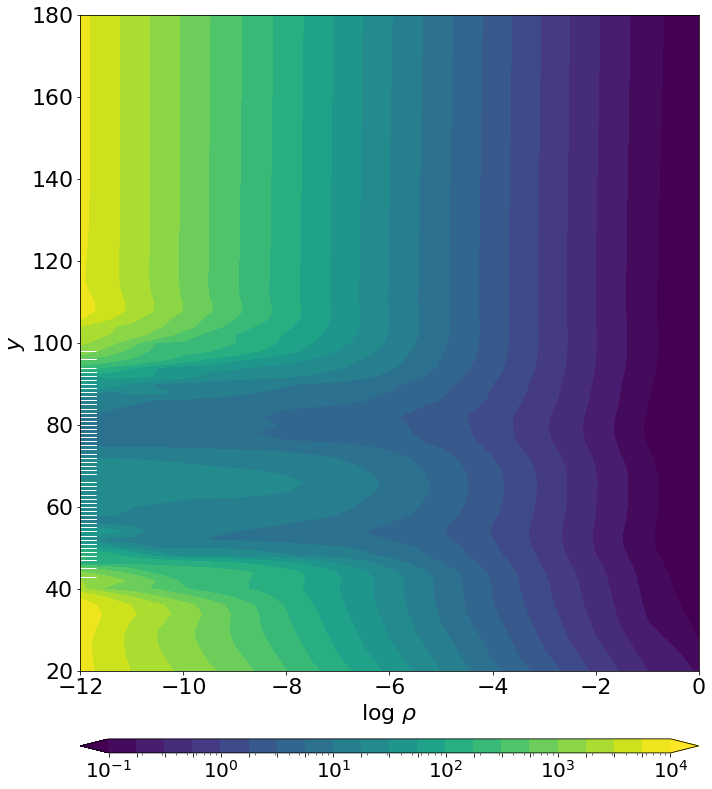

In [20]:
label_fontsize = 22
info_fontsize = 28
tick_fontsize = 20
legend_fontsize = 25
linewidth = 4.0

x_label = r'$\log \ \rho$'

rkhsnorm_min, rkhsnorm_max = np.min(plot_X_ml), np.max(plot_X_sm)

fig1, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (10, 13), sharex = 'all', sharey = 'row')
ax2 = axs

n_levels = 21
levels = np.logspace(-1, 4, n_levels)

cs2 = ax2.contourf(plot_X_sm_penparam, plot_Y_sm, plot_Z_sm, 
                    levels, 
                   extend = 'both',
                   locator = ticker.LogLocator(), 
                  #  cmap = cm.PuBu
                  )
# plt.clabel(cs2, inline = 1, fontsize = 15)
ax2.set_ylabel(r'$y$', fontsize = label_fontsize)
ax2.set_xlabel(x_label, fontsize = label_fontsize)

ax2.tick_params(labelsize=label_fontsize)
# ax2.set_xscale('log')
# ax2.set_title('Score Matching', fontsize = legend_fontsize)
# ax2.axhline(np.min(waiting), linewidth = linewidth, color = 'tab:olive')
# ax2.axhline(80., linewidth = linewidth, color = 'tab:olive')
ax2.set_xlim(-12., 0.)
sns.rugplot(y = pd.Series(waiting.flatten()), ax = ax2, color = 'white')

plt.tight_layout()

# plt.colorbar(cs1, ax = ax1, orientation="horizontal", ticks = levels, pad = 0.1)
cbar = plt.colorbar(cs2, ax = axs, orientation="horizontal", ticks = levels, pad = 0.08, aspect = 40)
cbar.ax.tick_params(labelsize = 20)

plt.savefig(f'../plots/PenSMFin-PenML-geyser-waiting-logdensity-empIF-supnorm-penaltyparameter-heatmap-bw={bw}-Gamma-36-2-gridpoints=1-202-1-logscale.pdf', 
           bbox_inches = 'tight')

plt.show()

## heatmap vs. (y and RKHS norm) --- both ML and SM

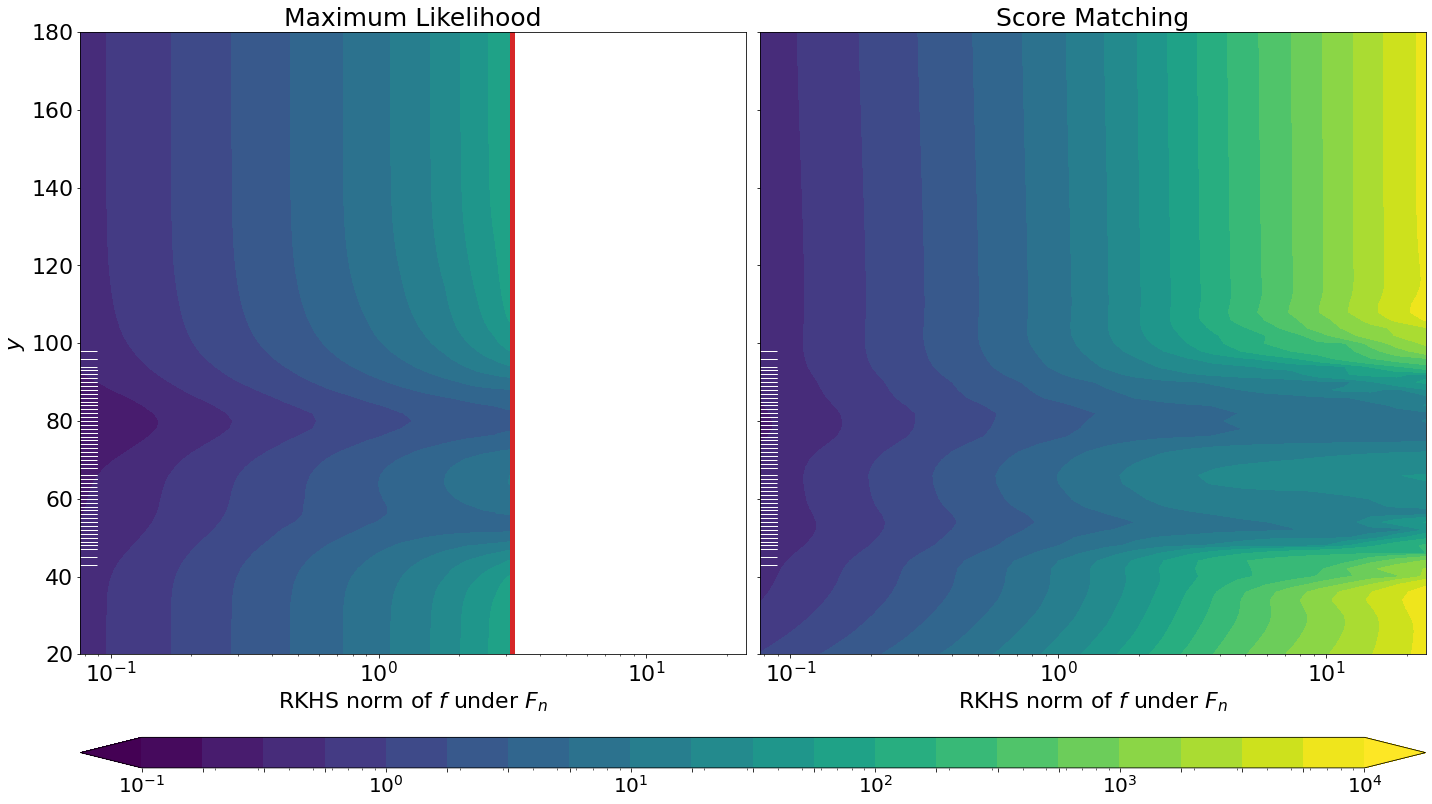

In [22]:
label_fontsize = 22
info_fontsize = 28
tick_fontsize = 20
legend_fontsize = 25
linewidth = 4.0

x_label = r'RKHS norm of $f$ under $F_n$'

rkhsnorm_min, rkhsnorm_max = np.min(plot_X_ml), np.max(plot_X_sm)

fig1, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 13), sharex = 'all', sharey = 'row')
ax1, ax2 = axs

n_levels = 21
# min_all = np.min([plot_Z_sm.min(), plot_Z_ml.min()])
# max_all = np.max([plot_Z_sm.max(), plot_Z_ml.max()])

levels = np.logspace(-1, 4, n_levels)

cs1 = ax1.contourf(plot_X_ml, plot_Y_ml, plot_Z_ml, 
                   levels, 
                   extend = 'both',
                   locator=ticker.LogLocator(), 
                  #  cmap = cm.OrRd
                  )
# plt.clabel(cs1, inline = 1, fontsize = 15)
ax1.set_ylabel(r'$y$', fontsize = label_fontsize)
ax1.set_xlabel(x_label, fontsize = label_fontsize)

# ax1.axhline(np.min(waiting), linewidth = linewidth, color = 'tab:olive')
# ax1.axhline(58., linewidth = linewidth, color = 'tab:olive')

ax1.tick_params(labelsize=label_fontsize)
ax1.set_xscale('log')
ax1.set_title('Maximum Likelihood', fontsize = legend_fontsize)
ax1.axvline(np.max(plot_X_ml), linewidth = 5.0, color = 'tab:red')
ax1.set_xlim(rkhsnorm_min, rkhsnorm_max)
sns.rugplot(y = pd.Series(waiting.flatten()), ax = ax1, color = 'white')

cs2 = ax2.contourf(plot_X_sm, plot_Y_sm, plot_Z_sm, 
                   levels, 
                   extend = 'both',
                   locator = ticker.LogLocator(), 
                  #  cmap = cm.PuBu
                  )
# plt.clabel(cs2, inline = 1, fontsize = 15)
# ax2.set_ylabel(r'$y$', fontsize = label_fontsize)
ax2.set_xlabel(x_label, fontsize = label_fontsize)

ax2.tick_params(labelsize=label_fontsize)
ax2.set_xscale('log')
ax2.set_title('Score Matching', fontsize = legend_fontsize)
# ax2.axhline(np.min(waiting), linewidth = linewidth, color = 'tab:olive')
# ax2.axhline(80., linewidth = linewidth, color = 'tab:olive')
ax2.set_xlim(rkhsnorm_min, rkhsnorm_max)
sns.rugplot(y = pd.Series(waiting.flatten()), ax = ax2, color = 'white')

plt.tight_layout()

# plt.colorbar(cs1, ax = ax1, orientation="horizontal", ticks = levels, pad = 0.1)
cbar = plt.colorbar(cs2, ax = axs, orientation="horizontal", ticks = levels, pad = 0.1, aspect = 40)
cbar.ax.tick_params(labelsize = 20)

plt.savefig(f'../plots/PenSMFin-PenML-geyser-waiting-logdensity-empIF-supnorm-natparamnorm-heatmap-bw={bw}-Gamma-36-2-gridpoints=1-202-1-logscale.pdf', 
           bbox_inches = 'tight')

plt.show()

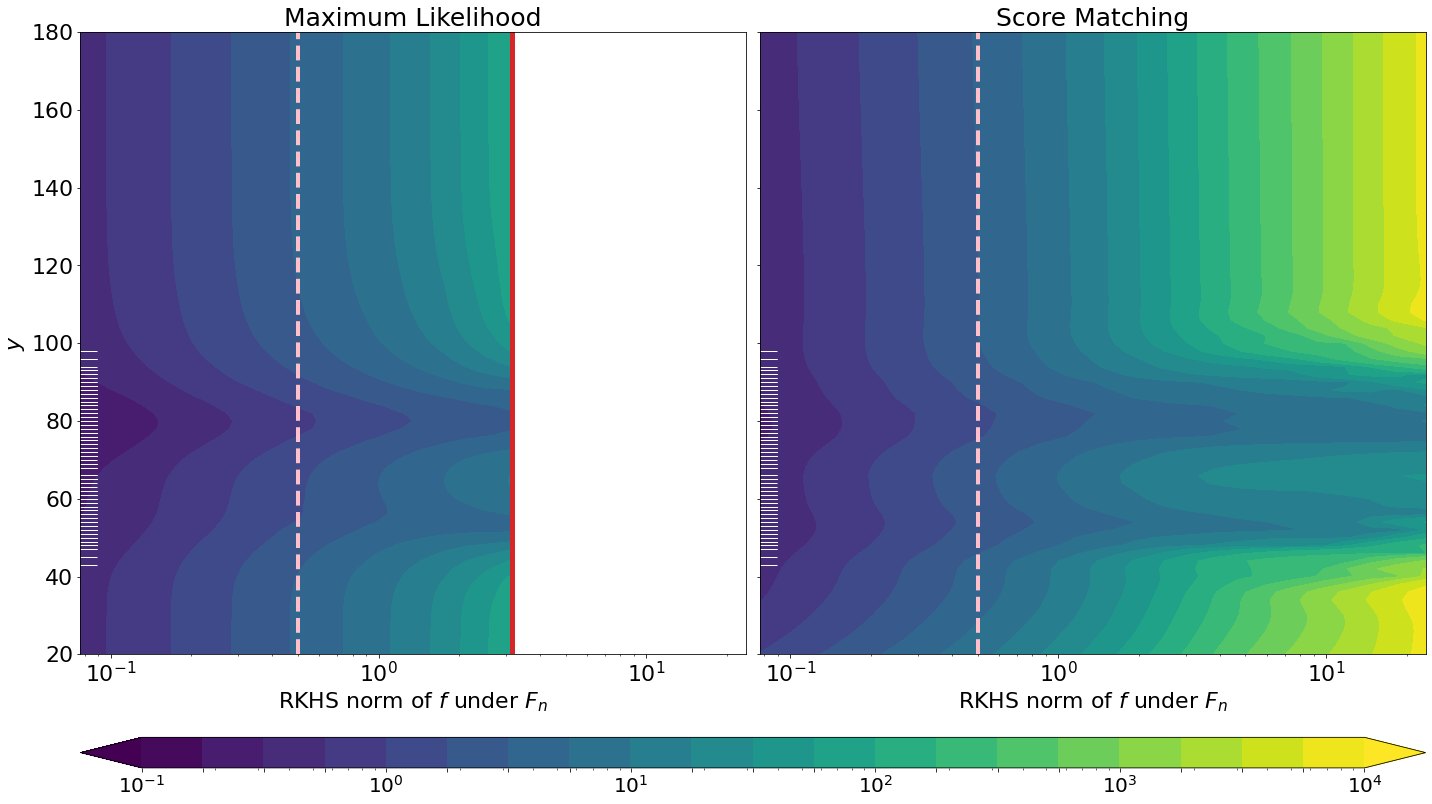

In [23]:
label_fontsize = 22
info_fontsize = 28
tick_fontsize = 20
legend_fontsize = 25
linewidth = 4.0

x_label = r'RKHS norm of $f$ under $F_n$'

rkhsnorm_min, rkhsnorm_max = np.min(plot_X_ml), np.max(plot_X_sm)

fig1, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 13), sharex = 'all', sharey = 'row')
ax1, ax2 = axs

n_levels = 21
# min_all = np.min([plot_Z_sm.min(), plot_Z_ml.min()])
# max_all = np.max([plot_Z_sm.max(), plot_Z_ml.max()])

levels = np.logspace(-1, 4, n_levels)

cs1 = ax1.contourf(plot_X_ml, plot_Y_ml, plot_Z_ml, 
                   levels, 
                   extend = 'both',
                   locator=ticker.LogLocator(), 
                  #  cmap = cm.OrRd
                  )
# plt.clabel(cs1, inline = 1, fontsize = 15)
ax1.set_ylabel(r'$y$', fontsize = label_fontsize)
ax1.set_xlabel(x_label, fontsize = label_fontsize)

ax1.axvline(0.5, linewidth = linewidth, linestyle = 'dashed', color = 'pink')
# ax1.axhline(58., linewidth = linewidth, color = 'tab:olive')

ax1.tick_params(labelsize=label_fontsize)
ax1.set_xscale('log')
ax1.set_title('Maximum Likelihood', fontsize = legend_fontsize)
ax1.axvline(np.max(plot_X_ml), linewidth = 5.0, color = 'tab:red')
# ax1.set_xlim(rkhsnorm_min, rkhsnorm_max)
sns.rugplot(y = pd.Series(waiting.flatten()), ax = ax1, color = 'white')

cs2 = ax2.contourf(plot_X_sm, plot_Y_sm, plot_Z_sm, 
                   levels, 
                   extend = 'both',
                   locator = ticker.LogLocator(), 
                  #  cmap = cm.PuBu
                  )
# plt.clabel(cs2, inline = 1, fontsize = 15)
# ax2.set_ylabel(r'$y$', fontsize = label_fontsize)
ax2.set_xlabel(x_label, fontsize = label_fontsize)

ax2.axvline(0.5, linewidth = linewidth, linestyle = 'dashed', color = 'pink')

ax2.tick_params(labelsize=label_fontsize)
ax2.set_xscale('log')
ax2.set_title('Score Matching', fontsize = legend_fontsize)
# ax2.axhline(np.min(waiting), linewidth = linewidth, color = 'tab:olive')
# ax2.axhline(80., linewidth = linewidth, color = 'tab:olive')
ax2.set_xlim(rkhsnorm_min, rkhsnorm_max)
sns.rugplot(y = pd.Series(waiting.flatten()), ax = ax2, color = 'white')

plt.tight_layout()

# plt.colorbar(cs1, ax = ax1, orientation="horizontal", ticks = levels, pad = 0.1)
cbar = plt.colorbar(cs2, ax = axs, orientation="horizontal", ticks = levels, pad = 0.1, aspect = 40)
cbar.ax.tick_params(labelsize = 20)

plt.savefig(f'../plots/PenSMFin-PenML-geyser-waiting-logdensity-empIF-supnorm-natparamnorm-heatmap-bw={bw}-Gamma-36-2-gridpoints=1-202-1-logscale-vertical-line.pdf', 
           bbox_inches = 'tight')

plt.show()

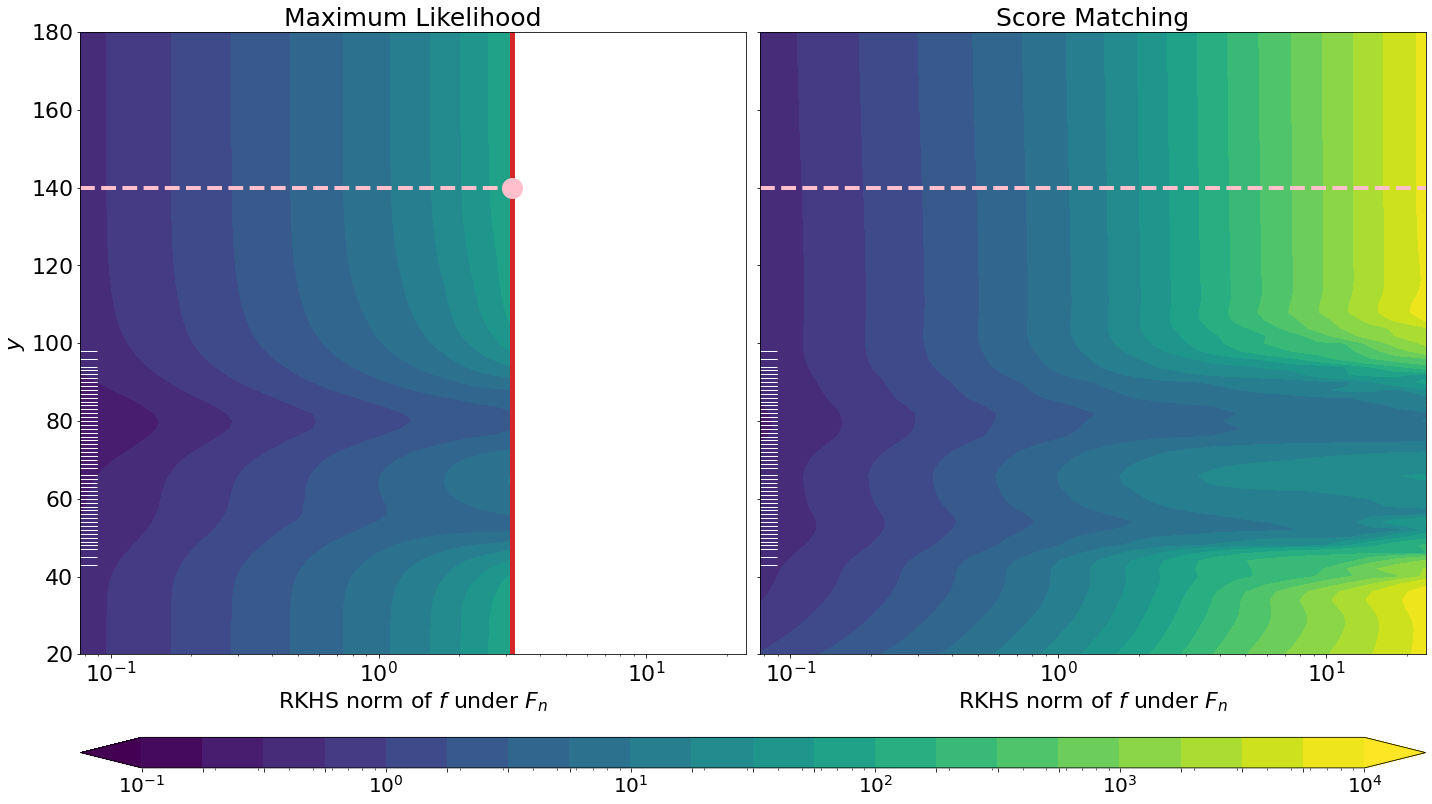

In [24]:
label_fontsize = 22
info_fontsize = 28
tick_fontsize = 20
legend_fontsize = 25
linewidth = 4.0

x_label = r'RKHS norm of $f$ under $F_n$'

rkhsnorm_min, rkhsnorm_max = np.min(plot_X_ml), np.max(plot_X_sm)

fig1, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (20, 13), sharex = 'all', sharey = 'row')
ax1, ax2 = axs

n_levels = 21
# min_all = np.min([plot_Z_sm.min(), plot_Z_ml.min()])
# max_all = np.max([plot_Z_sm.max(), plot_Z_ml.max()])

levels = np.logspace(-1, 4, n_levels)

cs1 = ax1.contourf(plot_X_ml, plot_Y_ml, plot_Z_ml, 
                   levels, 
                   extend = 'both',
                   locator=ticker.LogLocator(), 
                  #  cmap = cm.OrRd
                  )
# plt.clabel(cs1, inline = 1, fontsize = 15)
ax1.set_ylabel(r'$y$', fontsize = label_fontsize)
ax1.set_xlabel(x_label, fontsize = label_fontsize)

ax1.axhline(140, xmin = 0, xmax = 0.65, 
            linewidth = linewidth, linestyle = 'dashed', color = 'pink')

ax1.tick_params(labelsize=label_fontsize)
ax1.set_xscale('log')
ax1.set_title('Maximum Likelihood', fontsize = legend_fontsize)
ax1.axvline(np.max(plot_X_ml), linewidth = 5.0, color = 'tab:red')
ax1.plot(np.max(plot_X_ml), 140., marker = 'o', color = 'pink', markersize = 20)

ax1.set_xlim(rkhsnorm_min, rkhsnorm_max)
sns.rugplot(y = pd.Series(waiting.flatten()), ax = ax1, color = 'white')

cs2 = ax2.contourf(plot_X_sm, plot_Y_sm, plot_Z_sm, 
                   levels, 
                   extend = 'both',
                   locator = ticker.LogLocator(), 
                  #  cmap = cm.PuBu
                  )
# plt.clabel(cs2, inline = 1, fontsize = 15)
# ax2.set_ylabel(r'$y$', fontsize = label_fontsize)
ax2.set_xlabel(x_label, fontsize = label_fontsize)

ax2.axhline(140, linewidth = linewidth, linestyle = 'dashed', color = 'pink')

ax2.tick_params(labelsize=label_fontsize)
ax2.set_xscale('log')
ax2.set_title('Score Matching', fontsize = legend_fontsize)
# ax2.axhline(np.min(waiting), linewidth = linewidth, color = 'tab:olive')
# ax2.axhline(80., linewidth = linewidth, color = 'tab:olive')
ax2.set_xlim(rkhsnorm_min, rkhsnorm_max)
sns.rugplot(y = pd.Series(waiting.flatten()), ax = ax2, color = 'white')

plt.tight_layout()

# plt.colorbar(cs1, ax = ax1, orientation="horizontal", ticks = levels, pad = 0.1)
cbar = plt.colorbar(cs2, ax = axs, orientation="horizontal", ticks = levels, pad = 0.1, aspect = 40)
cbar.ax.tick_params(labelsize = 20)

plt.savefig(f'../plots/PenSMFin-PenML-geyser-waiting-logdensity-empIF-supnorm-natparamnorm-heatmap-bw={bw}-Gamma-36-2-gridpoints=1-202-1-logscale-horizontal-line.pdf', 
           bbox_inches = 'tight')

plt.show()

In [ ]:
# Score matching 
for i in contam_data_list: 
    
    print('*' * 50)
    print(f'contam data = {i}')
    
    df_sub = summary_df_ml[(summary_df_ml.contam_data == i)]
    
    df_sub = df_sub[df_sub.log_lambda >= -15.]
    plt.figure(figsize = (8, 8))
    
    plt.plot(df_sub.log_lambda, df_sub.IF_supnorm, 
             color = 'tab:blue', linestyle = 'solid', linewidth = linewidth)
    plt.plot(df_sub.log_lambda, df_sub.IF_supnorm, 
             color = 'tab:blue', marker = 'o', markersize = 10, label = 'emp')
    # plt.vlines(x = -6., ymin=0, ymax =100, color = 'k', linewidth = 4)
    
    # plt.xscale('log')
    # plt.loglog()
    plt.show()